In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [8]:
## Exercise 5.1
# Function to calculate option price using binomial model
def binomial_call_option(S0, K, T, r, sigma, N):
    '''
    S0 = initial stock price
    K = strike price
    T = time to maturity
    r = risk-free rate
    sigma = volatility
    N = number of time incriments 

    ouputs value of option from binomial tree
    '''

    dt = T / N
    u = np.exp(sigma * np.sqrt(dt)) 
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Initialize array for asset prices
    asset_prices = np.zeros(N + 1)
    for i in range(N + 1):
        asset_prices[i] = S0 * (u ** (N - i)) * (d ** i)

    # Initialize option values of each asset price at maturity
    option_values = np.maximum(0, asset_prices - K)

    # Work backwards through the tree
    for j in range(N - 1, -1, -1):
        for i in range(j + 1):
            option_values[i] = discount * (p * option_values[i] + (1 - p) * option_values[i + 1])

    return option_values[0]



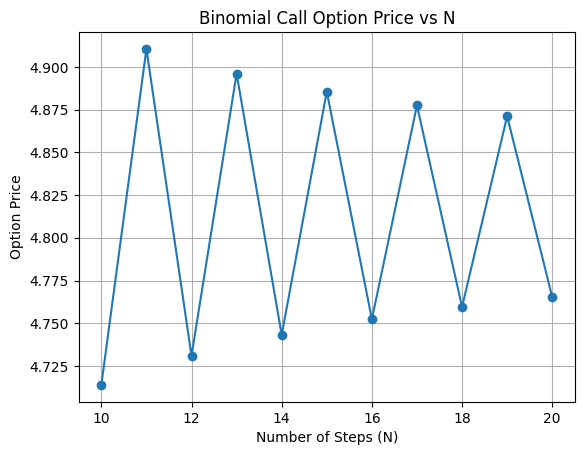

In [9]:
# Set Parameters
S0 = 50 
K = 50         
T = 0.5        
r = 0.05       
sigma = 0.30   
N_values = range(10, 21)  # N = 10, 11, ..., 20

# Compute option values for different N
option_values = []
for N in N_values:
    option_price = binomial_call_option(S0, K, T, r, sigma, N)
    option_values.append(option_price)

# Plot the option prices against N
plt.plot(N_values, option_values, marker='o')
plt.title("Binomial Call Option Price vs N")
plt.xlabel("Number of Steps (N)")
plt.ylabel("Option Price")
plt.grid(True)
plt.show()


In [14]:
## Exercise 5.2
# Black-Scholes call option pricing function
def black_scholes_call(S, K, r, sigma, q, T):
    if sigma == 0:
        black_scholes_price = max(0, np.exp(-q*T)*S - np.exp(-r*T)*K)
    else:
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        N1 = norm.cdf(d1)
        N2 = norm.cdf(d2)
        black_scholes_price = np.exp(-q*T)*S*N1 - np.exp(-r*T)*K*N2

    return black_scholes_price

In [16]:
black_scholes_price = black_scholes_call(S0, K, r, sigma, 0, T)
black_scholes_price

np.float64(4.817438314224592)

In [18]:
tolerance = 0.01     # Penny accuracy tolerance
N = 10

# Starting the price for N = 10
binomial_price = binomial_call_option(S0, K, T, r, sigma, N)

# Iterating through largers N's until price is within tolerance
while abs(binomial_price - black_scholes_price) > tolerance:
    N += 1
    binomial_price = binomial_call_option(S0, K, T, r, sigma, N)

print(binomial_price)
print('Value of N for penny accuracy:', N)

4.827289164265967
Value of N for penny accuracy: 103


In [19]:
## Exercise 5.3
# Binomial model for American and European put option
def binomial_put_option(S0, K, T, r, sigma, N, american=True):
    """
    S0 = initial stock price
    K = strike price
    T = time to maturity
    r = risk-free rate
    sigma = volatility
    N = number of time incriments
    american = True if american option, False for european

    outputs value of option from binomial tree
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))  
    d = 1 / u                        
    p = (np.exp(r * dt) - d) / (u - d)  
    discount = np.exp(-r * dt)  

    # Initialize array for asset prices
    asset_prices = np.zeros(N + 1)
    for i in range(N + 1):
        asset_prices[i] = S0 * (u ** (N - i)) * (d ** i)

    # Initialize option values of each asset price at maturity
    option_values = np.maximum(K - asset_prices, 0)

    # Work backwards through the tree
    for j in range(N - 1, -1, -1):
        for i in range(j + 1):
            # European option value
            option_values[i] = discount * (p * option_values[i] + (1 - p) * option_values[i + 1])

            # American option allows for early exercise
            if american:
                option_values[i] = np.maximum(option_values[i], K - S0 * (u ** (j - i)) * (d ** i))

    return option_values[0]

In [24]:
# Set Parameters   
T = 1          
sigma = 0.30   
N = 100        

# Interest rates, strike prices, and stock prices to try
interest_rates = [0.025, 0.05, 0.075]  
strike_prices = [45, 50, 55]         
stock_prices = [40, 50, 60]          

# Initialize an empty list to store the results
option_prices = []

# Loop over parameters and compute early exercise premium
for r in interest_rates:
    for K in strike_prices:
        for S in stock_prices:
            # European put price (no early exercise)
            european_put = binomial_put_option(S, K, T, r, sigma, N, american=False)
            
            # American put price (allow early exercise)
            american_put = binomial_put_option(S, K, T, r, sigma, N, american=True)
            
            # Early exercise premium
            premium = american_put - european_put
            
            # Organize results 
            option_prices.append({
                'Risk-Free Rate': r,
                'Strike Price': K,
                'Stock Price': S,
                'European Put Price': european_put,
                'American Put Price': american_put,
                'Early Exercise Premium': premium
            })

# Convert the results list into a DataFrame
df = pd.DataFrame(option_prices)
df.sort_values(by=['Early Exercise Premium'], ascending=False)

,Interest Rate,Strike Price,Stock Price,European Put Price,American Put Price,Early Exercise Premium
24,0.075,55,40,12.612150,15.000000,2.387850
21,0.075,50,40,8.956234,10.342821,1.386587
15,0.050,55,40,13.700684,15.080337,1.379653
12,0.050,50,40,9.841815,10.663896,0.822081
25,0.075,55,50,6.561251,7.341637,0.780386
18,0.075,45,40,5.786209,6.519190,0.732981
6,0.025,55,40,14.842038,15.398222,0.556183
16,0.050,55,50,7.340191,7.819213,0.479021
9,0.050,45,40,6.453758,6.901930,0.448172
22,0.075,50,50,4.102415,4.521336,0.418920


In [25]:
## Exercise 5.4
# Function to compute call option price using GARCH Monte Carlo
def eur_call_garch_mc(S, K, r, sigma0, q, T, N, kappa, theta, Lambda, M):
    dt = T / N
    sqrdt = np.sqrt(dt)
    a = kappa * theta
    b = (1 - kappa) * Lambda
    c = (1 - kappa) * (1 - Lambda)
    logS0 = np.log(S)
    
    sum_call = 0
    sum_call_sq = 0

    # Monte Carlo simulations
    for i in range(M):
        logS = logS0
        sigma = sigma0
        
        # Generate path
        for j in range(N):
            y = sigma * np.random.randn()  # Standard normal random variable
            logS = logS + (r - q - 0.5 * sigma**2) * dt + sqrdt * y
            sigma = np.sqrt(a + b * y**2 + c * sigma**2)  # Update volatility

        # Compute the call payoff at time T
        call_value = max(0, np.exp(logS) - K)
        sum_call += call_value
        sum_call_sq += call_value**2

    # Average call price and standard error
    call_value_avg = np.exp(-r * T) * sum_call / M
    std_error = np.exp(-r * T) * np.sqrt((sum_call_sq - sum_call**2 / M) / (M * (M - 1)))

    return call_value_avg, std_error

In [27]:
# Implied volatility function provided
def implied_volatility_grid(S, K, r, q, T, S_mkt):
    volatilities = np.linspace(0.01, 2, 500)  # Search range for volatilities
    min_diff = float(9999999999)
    implied_vol = 0.01

    # Search for implied volatility
    for sigma in volatilities:
        price = black_scholes_call(S, K, r, sigma, q, T)
        diff = abs(price - S_mkt)
        if diff < min_diff:
            min_diff = diff
            implied_vol = sigma 

    return implied_vol

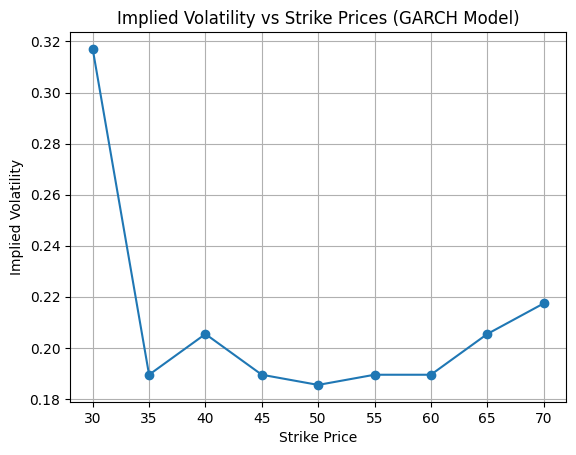

In [35]:
# User inputs for the model parameters
S = 50           
r = 0.05         
sigma0 = 0.30    
q = 0.02         
T = 1            
N = 100          
kappa = 0.2      
theta = 0.04     
Lambda = 0.9      
M = 10000         

# Strike prices to loop through
strike_prices = np.array([0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]) * S

# Arrays to store results
call_prices = []
implied_vols = []

# Loop over strike prices and compute GARCH call prices and implied volatilities
for K in strike_prices:
    call_price, std_error = eur_call_garch_mc(S, K, r, sigma0, q, T, N, kappa, theta, Lambda, M)
    call_prices.append(call_price)

    implied_vol = implied_volatility_grid(S, K, r, q, T, call_price)
    implied_vols.append(implied_vol)

# Convert results to numpy arrays
call_prices = np.array(call_prices)
implied_vols = np.array(implied_vols)

# Plot implied volatilities against strike prices
plt.plot(strike_prices, implied_vols, marker='o')
plt.title("Implied Volatility vs Strike Prices (GARCH Model)")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.show()